In [34]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

In [11]:
url = 'https://raw.githubusercontent.com/dvisa7178/challengeTelecomX_pt2/refs/heads/main/telecom_x_tratado.csv'

In [12]:
colunas_relevantes = [
    "Churn", "tenure", "Contract", "PaymentMethod",
    "Charges.Monthly", "Charges.Total", "Contas_Diarias",
    "InternetService", "OnlineSecurity", "TechSupport",
    "OnlineBackup", "DeviceProtection", "StreamingTV",
    "StreamingMovies", "PaperlessBilling", "MultipleLines",
    "PhoneService", "SeniorCitizen", "Partner", "Dependents"
]

df = pd.read_csv(url, usecols=colunas_relevantes)
print("Shape:", df.shape)
df.head()

Shape: (7043, 20)


,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Contas_Diarias
0,0,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,1,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,1,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,1,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [13]:
colunas_categoricas = [
    "MultipleLines", "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
    "Contract", "PaymentMethod"
]

df = pd.get_dummies(df, columns=colunas_categoricas, drop_first=False)

print("Shape após encoding:", df.shape)
print("\nColunas geradas:")
print(df.columns.tolist())

Shape após encoding: (7043, 41)

Colunas geradas:
['Churn', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total', 'Contas_Diarias', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electron

In [14]:
df.head()

,Churn,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,Contas_Diarias,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,True,False,False,False,True,False,False,False,False,True
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,False,False,True,True,False,False,False,False,False,True
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,True,False,False,True,False,False,False,False,True,False
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,False,False,True,True,False,False,False,False,True,False
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,True,False,False,True,False,False,False,False,False,True


In [18]:
contagem = df["Churn"].value_counts()
proporcao = df["Churn"].value_counts(normalize=True) * 100

df_balanceamento = pd.DataFrame({
    "Quantidade": contagem,
    "Proporção (%)": proporcao.round(2)
})
df_balanceamento.index = ["Não Cancelou (0)", "Cancelou (1)"]
df_balanceamento

,Quantidade,Proporção (%)
Não Cancelou (0),5174,73.46
Cancelou (1),1869,26.54


In [21]:
colunas_numericas = ["tenure", "Charges.Monthly", "Charges.Total", "Contas_Diarias"]

X = df.drop(columns=["Churn"])
y = df["Churn"]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[colunas_numericas] = scaler.fit_transform(X[colunas_numericas])
display(X_scaled[colunas_numericas].head())

,tenure,Charges.Monthly,Charges.Total,Contas_Diarias
0,-0.951682,0.027862,-0.744076,0.031231
1,-0.951682,-0.161583,-0.766533,-0.158198
2,-1.155283,0.303720,-0.881927,0.300419
3,-0.788800,1.104706,-0.459703,1.107982
4,-1.196004,0.636080,-0.887861,0.639396


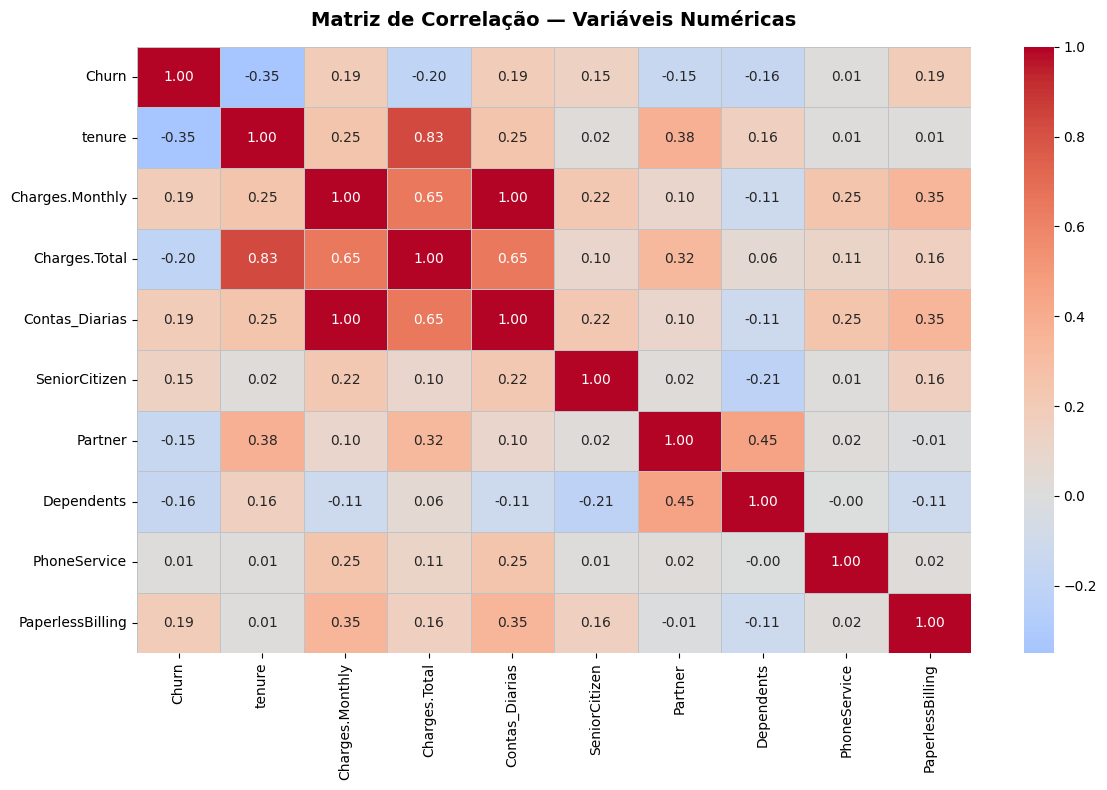


Correlação das variáveis com Churn (ordenado):


,Churn
Charges.Monthly,0.19
PaperlessBilling,0.19
Contas_Diarias,0.19
SeniorCitizen,0.15
PhoneService,0.01
Partner,-0.15
Dependents,-0.16
Charges.Total,-0.20
tenure,-0.35


In [22]:
colunas_correlacao = ["Churn", "tenure", "Charges.Monthly", "Charges.Total", "Contas_Diarias", "SeniorCitizen", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

matriz_correlacao = df[colunas_correlacao].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="#BDC3C7",
    ax=ax
)

ax.set_title("Matriz de Correlação — Variáveis Numéricas", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

print("\nCorrelação das variáveis com Churn (ordenado):")
display(matriz_correlacao["Churn"].drop("Churn").sort_values(ascending=False).to_frame())

/tmp/ipykernel_882/2905332435.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="tenure", palette=palette, ax=axes[0])
/tmp/ipykernel_882/2905332435.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="Charges.Total", palette=palette, ax=axes[1])


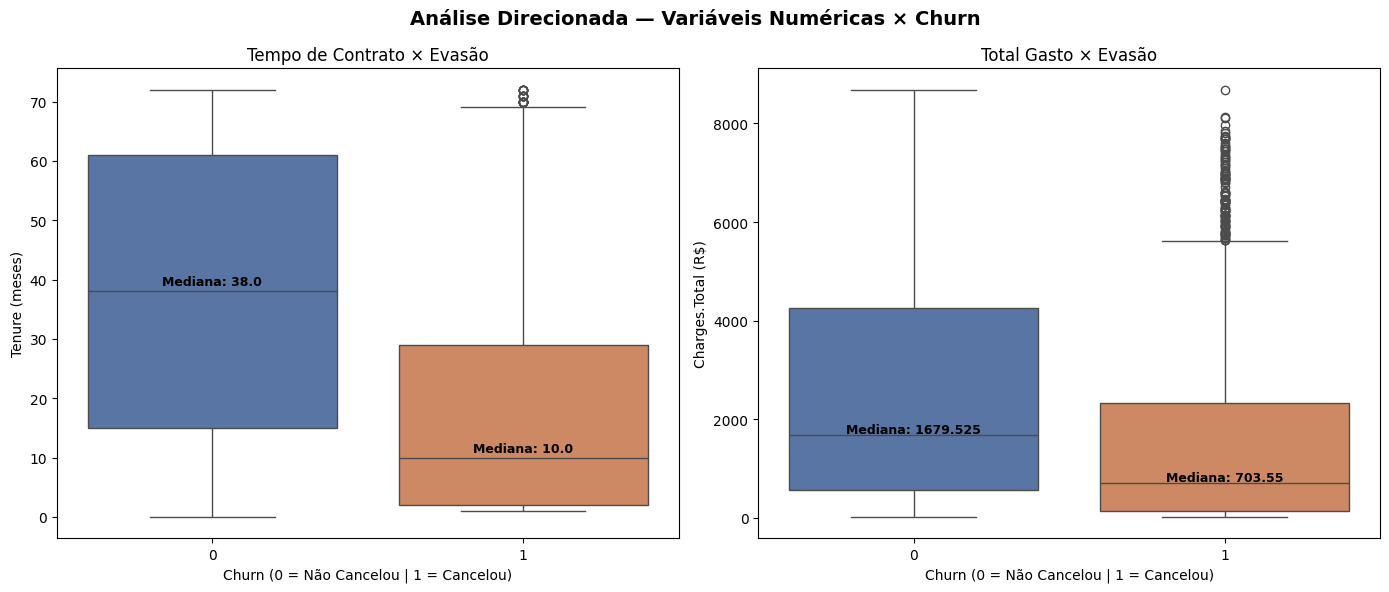

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Análise Direcionada — Variáveis Numéricas × Churn", fontsize=14, fontweight="bold")

palette = {"0": "#4C72B0", "1": "#DD8452"}
df["Churn"] = df["Churn"].astype(str)

sns.boxplot(data=df, x="Churn", y="tenure", palette=palette, ax=axes[0])
axes[0].set_title("Tempo de Contrato × Evasão")
axes[0].set_xlabel("Churn (0 = Não Cancelou | 1 = Cancelou)")
axes[0].set_ylabel("Tenure (meses)")
medians = df.groupby("Churn")["tenure"].median()
for i, (churn, median) in enumerate(medians.items()):
    axes[0].text(i, median + 1, f"Mediana: {median}", ha="center", fontsize=9, fontweight="bold")

sns.boxplot(data=df, x="Churn", y="Charges.Total", palette=palette, ax=axes[1])
axes[1].set_title("Total Gasto × Evasão")
axes[1].set_xlabel("Churn (0 = Não Cancelou | 1 = Cancelou)")
axes[1].set_ylabel("Charges.Total (R$)")
medians = df.groupby("Churn")["Charges.Total"].median()
for i, (churn, median) in enumerate(medians.items()):
    axes[1].text(i, median + 50, f"Mediana: {median}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

df["Churn"] = df["Churn"].astype(int)

/tmp/ipykernel_882/972434524.py:13: MatplotlibDeprecationWarning: You have mixed positional and keyword arguments, some input may be discarded.  This is deprecated since 3.9 and will become an error in 3.11.
  legend = ax.legend(*scatter.legend_elements(), title="Churn", labels=["Não Cancelou (0)", "Cancelou (1)"])


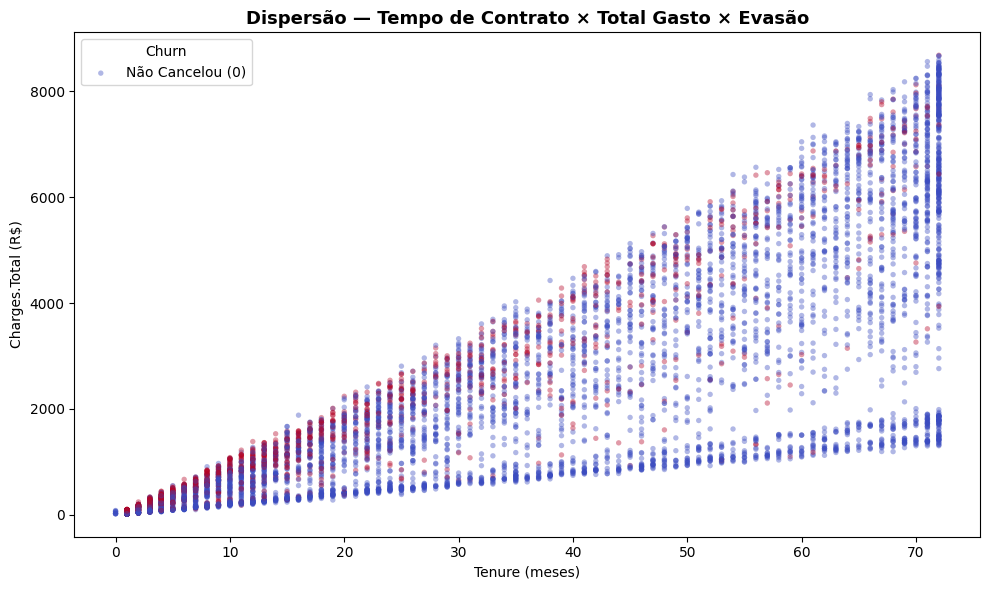

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    df["tenure"],
    df["Charges.Total"],
    c=df["Churn"],
    cmap="coolwarm",
    alpha=0.4,
    edgecolors="none",
    s=15
)

legend = ax.legend(*scatter.legend_elements(), title="Churn", labels=["Não Cancelou (0)", "Cancelou (1)"])
ax.set_title("Dispersão — Tempo de Contrato × Total Gasto × Evasão", fontsize=13, fontweight="bold")
ax.set_xlabel("Tenure (meses)")
ax.set_ylabel("Charges.Total (R$)")
plt.tight_layout()
plt.show()

In [29]:
X = df.drop(columns=["Churn"])
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Total de amostras:   {len(df)}")
print(f"Treino:              {X_train.shape[0]} ({X_train.shape[0]/len(df)*100:.1f}%)")
print(f"Teste:               {X_test.shape[0]} ({X_test.shape[0]/len(df)*100:.1f}%)")

Total de amostras:   7043
Treino:              5634 (80.0%)
Teste:               1409 (20.0%)


# Modelos: Regressão Logística e Random Forest

Regressão Logística

In [31]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

modelo_lr = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
modelo_lr.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

Justificativa:
- Modelo linear interpretável, ideal para entender o peso de cada variável no churn.
- Sensível à escala: requer normalização para convergir corretamente.
- class_weight='balanced' compensa o desbalanceamento das classes (73/27).


Random Forest

In [33]:
modelo_rf = RandomForestClassifier(random_state=42, n_estimators=100, class_weight="balanced")
modelo_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

Justificativa:
- Modelo baseado em árvores de decisão: não é sensível à escala dos dados.
- Robusto a outliers e variáveis com distribuições assimétricas, como Charges.Total.
- Captura relações não-lineares entre variáveis, o que a Regressão Logística não faz.
- class_weight='balanced' compensa o desbalanceamento das classes (73/27).

In [36]:
def avaliar_modelo(nome, modelo, X_treino, X_teste, y_treino, y_teste):
    y_pred_treino = modelo.predict(X_treino)
    y_pred_teste  = modelo.predict(X_teste)

    metricas = {
        "Acurácia":  [accuracy_score(y_treino, y_pred_treino),  accuracy_score(y_teste, y_pred_teste)],
        "Precisão":  [precision_score(y_treino, y_pred_treino), precision_score(y_teste, y_pred_teste)],
        "Recall":    [recall_score(y_treino, y_pred_treino),    recall_score(y_teste, y_pred_teste)],
        "F1-Score":  [f1_score(y_treino, y_pred_treino),        f1_score(y_teste, y_pred_teste)],
    }

    df_metricas = pd.DataFrame(metricas, index=["Treino", "Teste"]).round(4) * 100

    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    display(df_metricas)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"Matriz de Confusão — {nome}", fontweight="bold")
    for ax, (conjunto, y_real, y_pred) in zip(axes, [
        ("Treino", y_treino, y_pred_treino),
        ("Teste",  y_teste,  y_pred_teste)
    ]):
        cm = confusion_matrix(y_real, y_pred)
        ConfusionMatrixDisplay(cm, display_labels=["Não Cancelou", "Cancelou"]).plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(conjunto)
    plt.tight_layout()
    plt.show()

    return df_metricas


  Regressão Logística


,Acurácia,Precisão,Recall,F1-Score
Treino,75.24,52.15,81.00,63.45
Teste,73.95,50.60,78.61,61.57


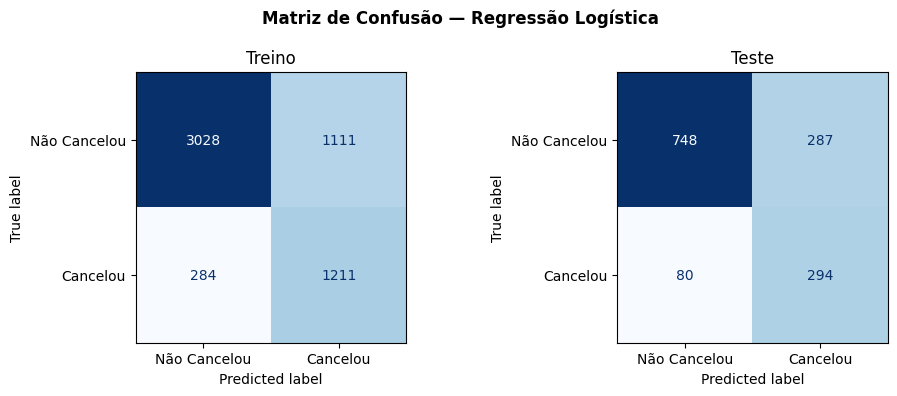


  Random Forest


,Acurácia,Precisão,Recall,F1-Score
Treino,99.72,99.27,99.67,99.47
Teste,78.64,62.90,47.59,54.19


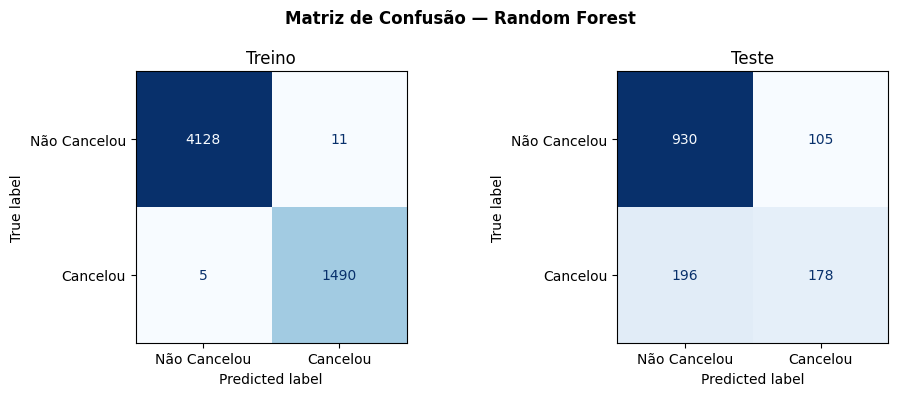

In [37]:
metricas_lr = avaliar_modelo("Regressão Logística", modelo_lr, X_train_scaled, X_test_scaled, y_train, y_test)
metricas_rf = avaliar_modelo("Random Forest",modelo_rf, X_train,X_test,y_train, y_test)

Comparação — Desempenho no Conjunto de Teste (%)


,Acurácia,Precisão,Recall,F1-Score
Regressão Logística,73.95,50.6,78.61,61.57
Random Forest,78.64,62.9,47.59,54.19


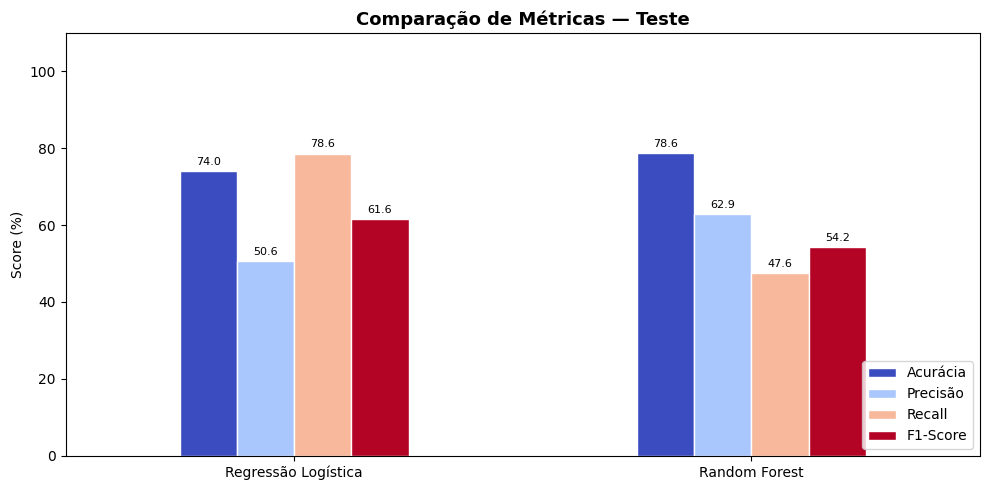

In [38]:
df_comparacao = pd.DataFrame({
    "Regressão Logística": metricas_lr.loc["Teste"],
    "Random Forest":       metricas_rf.loc["Teste"]
}).T

print("Comparação — Desempenho no Conjunto de Teste (%)")
display(df_comparacao)

fig, ax = plt.subplots(figsize=(10, 5))
df_comparacao.plot(kind="bar", ax=ax, colormap="coolwarm", edgecolor="white", width=0.5)
ax.set_title("Comparação de Métricas — Teste", fontsize=13, fontweight="bold")
ax.set_ylabel("Score (%)")
ax.set_xticklabels(df_comparacao.index, rotation=0)
ax.legend(loc="lower right")
ax.set_ylim(0, 110)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

Análise crítica

Regressão Logística (Teste):
  Acurácia: 73.95% | Precisão: 50.6% | Recall: 78.61% | F1: 61.57%

- Desempenho equilibrado entre treino e teste → boa generalização, sem overfitting.
- Recall alto (78.61%): identifica bem os clientes que vão cancelar, sendo o
  modelo mais eficaz para o objetivo de retenção.
- Precisão baixa (50.6%): metade dos alertas de cancelamento são falsos positivos,
  o que pode gerar custos desnecessários em ações de retenção.

Random Forest (Teste):
  Acurácia: 78.64% | Precisão: 62.9% | Recall: 47.59% | F1: 54.19%

- Treino quase perfeito (acurácia ~99%) vs Teste (78.64%) → possui overfitting.
  O modelo memorizou os dados de treino e perdeu capacidade de generalização.
- Recall baixo (47.59%): deixa escapar mais da metade dos clientes que cancelam.
- Precisão maior (62.9%): quando prevê cancelamento, acerta mais que a LR.

 Conclusão:
- Para o problema de churn, a Regressão Logística é superior.
- Recall é a métrica mais crítica: perder um cliente que vai cancelar
  é mais custoso do que acionar retenção para quem ficaria.
- O Random Forest precisa de ajustes: limitar max_depth, aumentar
  min_samples_leaf ou aplicar poda para reduzir o overfitting.

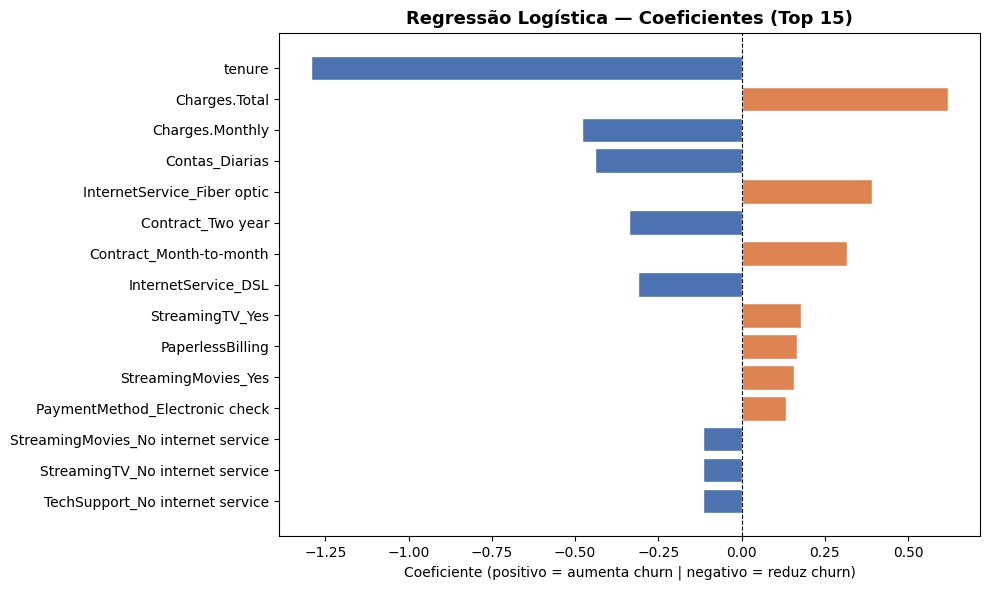

In [39]:
import numpy as np

coeficientes = pd.DataFrame({
    "Variável": X_train.columns,
    "Coeficiente": modelo_lr.coef_[0]
}).sort_values("Coeficiente", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
cores = ["#DD8452" if c > 0 else "#4C72B0" for c in coeficientes["Coeficiente"]]
ax.barh(coeficientes["Variável"], coeficientes["Coeficiente"], color=cores, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Regressão Logística — Coeficientes (Top 15)", fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente (positivo = aumenta churn | negativo = reduz churn)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

/tmp/ipykernel_882/2255850554.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importancias, x="Importância", y="Variável", palette="coolwarm_r", ax=ax)


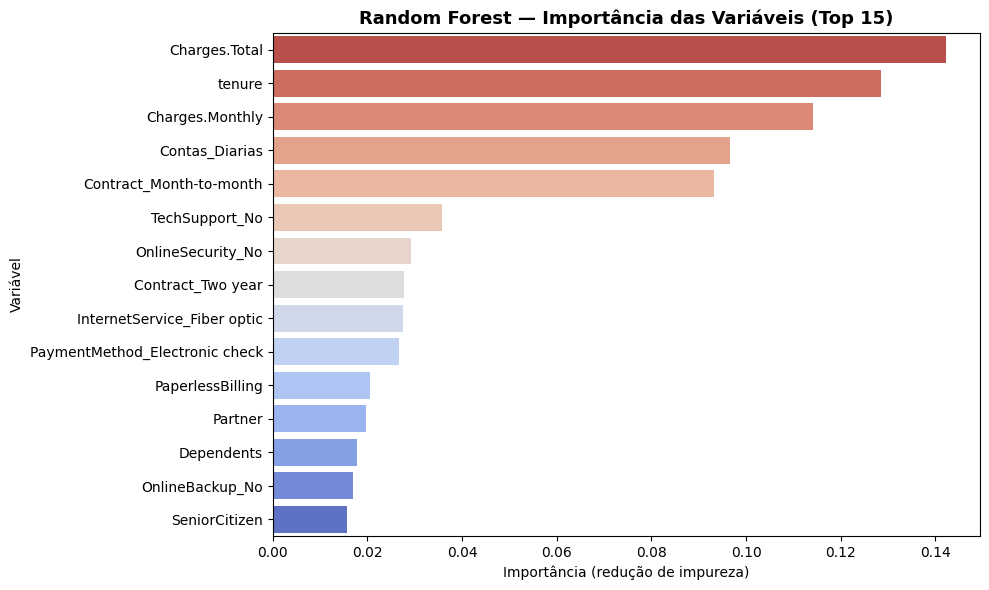

In [40]:
importancias = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": modelo_rf.feature_importances_
}).sort_values("Importância", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=importancias, x="Importância", y="Variável", palette="coolwarm_r", ax=ax)
ax.set_title("Random Forest — Importância das Variáveis (Top 15)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importância (redução de impureza)")
plt.tight_layout()
plt.show()

# Relatório Final — Modelos Preditivos de Evasão de Clientes | Telecom X

---

## 1. Introdução

Este relatório apresenta os resultados da segunda fase do projeto de análise de evasão da **Telecom X**,
focada na construção e avaliação de modelos preditivos de *Churn*. O objetivo é antecipar quais clientes
têm maior probabilidade de cancelar o serviço, permitindo ações proativas de retenção.

Foram desenvolvidos dois modelos preditivos com abordagens complementares:
- **Regressão Logística** — modelo linear, interpretável, sensível à escala
- **Random Forest** — modelo baseado em árvores, robusto a não-linearidades

---

## 2. Preparação dos Dados

Antes da modelagem, os dados passaram pelas seguintes etapas:

- **Seleção de variáveis**: Removidas colunas irrelevantes como `customerID`
- **Encoding**: Variáveis categóricas convertidas via *One-Hot Encoding*, expandindo o dataset de 20 para 41 colunas
- **Balanceamento**: Classes desbalanceadas tratadas com `class_weight='balanced'` em ambos os modelos
- **Normalização**: Aplicada via `StandardScaler` exclusivamente para a Regressão Logística
- **Divisão**: 80% treino e 20% teste, com `stratify=y` para preservar a proporção de churn em ambos os conjuntos

---

## 3. Desempenho dos Modelos

| Métrica    | Regressão Logística | Random Forest |
|------------|--------------------:|------------------:|
| Acurácia   | 73,95%              | 78,64%            |
| Precisão   | 50,60%              | 62,90%            |
| Recall     | **78,61%**          | 47,59%            |
| F1-Score   | **61,57%**          | 54,19%            |

### 3.1 Regressão Logística
- Apresentou **Recall de 78,61%**, identificando corretamente a maioria dos clientes que cancelaram
- Desempenho consistente entre treino e teste, indicando **boa capacidade de generalização**
- Precisão de 50,6% indica geração de falsos positivos, mas aceitável dado o contexto de retenção

### 3.2 Random Forest
- Acurácia de ~99% no treino contra 78,64% no teste evidencia **overfitting**
- Recall baixo (47,59%) significa que o modelo deixa escapar mais da metade dos clientes que cancelam
- Para mitigar o overfitting, recomenda-se limitar `max_depth`, aumentar `min_samples_leaf` ou aplicar poda

### 3.3 Modelo Recomendado
> A **Regressão Logística** é o modelo mais adequado para este problema. Em *Churn*, **Recall é a métrica
> prioritária**: o custo de não identificar um cliente que vai cancelar supera o custo de acionar
> retenção para quem ficaria. O F1-Score superior (61,57%) confirma o melhor equilíbrio geral.

---

## 4. Principais Fatores de Evasão

Com base nos coeficientes da Regressão Logística e na importância das variáveis do Random Forest,
os fatores que mais influenciam o cancelamento são:

### Fatores que aumentam o risco de evasão
| Fator | Evidência |
|---|---|
| **Contrato mensal** | 42,7% de churn — maior taxa entre todos os tipos de contrato |
| **Fibra óptica** | 41,9% de churn — alto apesar de ser serviço premium |
| **Pagamento por cheque eletrônico** | 45,3% de churn — método mais associado ao cancelamento |
| **Cobrança mensal elevada** | Clientes com maiores gastos mensais cancelam mais |
| **Ausência de serviços adicionais** | Sem segurança online, suporte técnico ou backup aumenta o risco |

### Fatores que reduzem o risco de evasão
| Fator | Evidência |
|---|---|
| **Longo tempo de contrato (tenure)** | Mediana de 38 meses para quem ficou vs 10 meses para quem saiu |
| **Contrato anual ou bienal** | Taxa de churn de apenas 2,8% nos contratos de dois anos |
| **Pagamento automático** | Débito automático e cartão têm taxas ~15–16% de churn |
| **Presença de dependentes ou parceiro** | Correlação negativa com o churn |

---

## 5. Estratégias de Retenção

Com base nos fatores identificados, propõem-se as seguintes ações:

**1. Programa de migração contratual**
Oferecer descontos progressivos para clientes em contrato mensal migrarem para planos anuais ou bianuais,
reduzindo o risco de cancelamento em até 40 pontos percentuais.

**2. Revisão do serviço de fibra óptica**
Realizar pesquisas de satisfação com assinantes de fibra óptica para identificar causas do alto churn
(qualidade, preço, expectativas). Considerar pacotes com melhor custo-benefício para este segmento.

**3. Incentivo à troca do método de pagamento**
Clientes que pagam via cheque eletrônico têm o maior índice de cancelamento. Oferecer benefícios
(desconto, bônus) para migração ao débito automático ou cartão de crédito.

**4. Onboarding estruturado para novos clientes**
A evasão é concentrada nos primeiros meses. Criar um programa de acompanhamento ativo nos 3 primeiros
meses de contrato, com suporte proativo e ofertas de serviços adicionais.

**5. Ofertas de serviços adicionais como âncora**
Clientes sem segurança online, suporte técnico ou backup cancelam mais. Oferecer esses serviços
gratuitamente por período limitado pode aumentar o engajamento e reduzir a propensão ao cancelamento.

**6. Modelo preditivo em produção**
Implementar a Regressão Logística em produção para gerar scores de risco mensalmente, acionando
automaticamente a equipe de retenção para clientes com alta probabilidade de cancelamento.

---

## 6. Conclusão

A análise confirma que a evasão na Telecom X está fortemente ligada a **fatores contratuais e financeiros**,
e não a características demográficas como gênero. Clientes novos, com contratos flexíveis, altas cobranças
mensais e métodos de pagamento manuais formam o perfil de maior risco.

A **Regressão Logística** demonstrou ser o modelo mais adequado para este cenário, com alta capacidade de
identificar clientes em risco antes que o cancelamento ocorra. Com as estratégias propostas e o modelo
em produção, a Telecom X tem condições de reduzir significativamente sua taxa de evasão.